In [3]:
# https://huggingface.co/Felix92/onnxtr-mobilenet-v3-small-page-orientation
# %pip install onnxruntime huggingface_hub pillow matplotlib

REPO = "Felix92/onnxtr-mobilenet-v3-small-page-orientation"
# IMG_PATH = "/mnt/DATA2/dorin/images/test_htr/1.jpg"
IMG_PATH = "/mnt/DATA2/dorin/images/test_htr/3.jpg"

In [21]:
import numpy as np
import onnxruntime as ort
from huggingface_hub import hf_hub_download

CLASSES = [0, -90, 180, 90]          # на сколько повернута страница (против часовой «+»)
MEAN = np.array([0.694, 0.695, 0.693], np.float32)
STD  = np.array([0.299, 0.296, 0.301], np.float32)
SIZE = 512

sess = ort.InferenceSession(hf_hub_download(REPO, "model.onnx"))
INPUT = sess.get_inputs()[0].name

In [22]:
def resize_bilinear(img, out_h, out_w):
    # билинейный resize на чистом numpy (полупиксельные центры, как cv.INTER_LINEAR)
    h, w = img.shape[:2]
    ys = (np.arange(out_h, dtype=np.float32) + 0.5) * (h / out_h) - 0.5
    xs = (np.arange(out_w, dtype=np.float32) + 0.5) * (w / out_w) - 0.5
    y0f, x0f = np.floor(ys), np.floor(xs)
    wy = (ys - y0f)[:, None, None]
    wx = (xs - x0f)[None, :, None]
    y0 = np.clip(y0f,     0, h - 1).astype(np.intp)
    y1 = np.clip(y0f + 1, 0, h - 1).astype(np.intp)
    x0 = np.clip(x0f,     0, w - 1).astype(np.intp)
    x1 = np.clip(x0f + 1, 0, w - 1).astype(np.intp)
    im = img.astype(np.float32)
    top = im[y0][:, x0] * (1 - wx) + im[y0][:, x1] * wx
    bot = im[y1][:, x0] * (1 - wx) + im[y1][:, x1] * wx
    return top * (1 - wy) + bot * wy


def predict_orientation(img_rgb):
    # препроцесс docTR: resize с сохранением пропорций + симметричный паддинг до SIZE x SIZE
    h, w = img_rgb.shape[:2]
    scale = SIZE / max(h, w)
    nh, nw = max(1, round(h * scale)), max(1, round(w * scale))
    canvas = np.zeros((SIZE, SIZE, 3), np.float32)
    top, left = (SIZE - nh) // 2, (SIZE - nw) // 2
    canvas[top:top + nh, left:left + nw] = resize_bilinear(img_rgb, nh, nw) / 255.0
    x = ((canvas - MEAN) / STD).transpose(2, 0, 1)[None]

    logits = sess.run(None, {INPUT: x.astype(np.float32)})[0][0]
    e = np.exp(logits - logits.max())
    p = e / e.sum()
    i = int(p.argmax())
    return CLASSES[i], float(p[i])


def straighten(img_rgb, angle):
    # выпрямление обратным поворотом (np.rot90 крутит против часовой)
    return np.rot90(img_rgb, (-int(angle) // 90) % 4)

angle=0°  conf=0.675


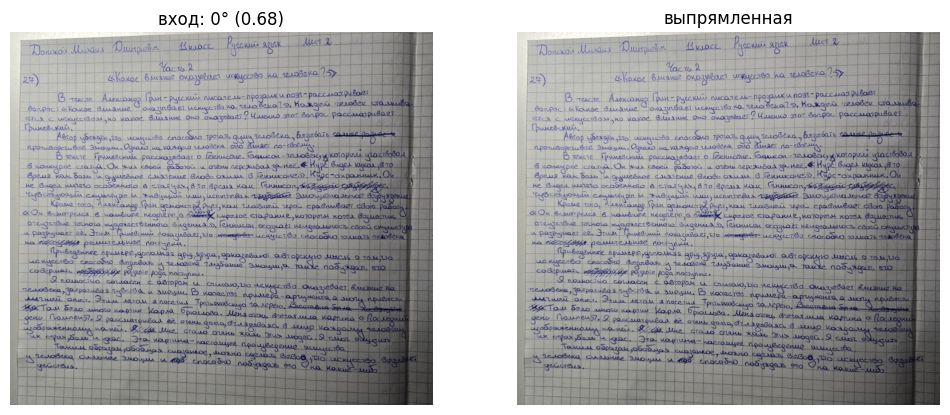

In [23]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

img = np.asarray(ImageOps.exif_transpose(Image.open(IMG_PATH)).convert("RGB"))

angle, conf = predict_orientation(img)
print(f"angle={angle}°  conf={conf:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img);                    ax[0].set_title(f"вход: {angle}° ({conf:.2f})")
ax[1].imshow(straighten(img, -angle)); ax[1].set_title("выпрямленная")
for a in ax: a.axis("off")
plt.show()

In [24]:
# (необязательно) потестить другие повороты той же картинки
for k in range(4):
    a, c = predict_orientation(np.rot90(img, k))
    print(f"rot90 x{k}: pred {a}°  conf {c:.2f}")

rot90 x0: pred 0°  conf 0.68
rot90 x1: pred 90°  conf 0.45
rot90 x2: pred 0°  conf 0.64
rot90 x3: pred 90°  conf 0.46


### Torch оригинал

In [19]:
# !pip install "python-doctr[torch]"
# !pip uninstall -y opencv-python opencv-contrib-python && pip install opencv-python-headless
# !apt-get update && sudo apt-get install -y libgl1 libglib2.0-0
import numpy as np
from PIL import Image, ImageOps
from doctr.models import page_orientation_predictor

predictor = page_orientation_predictor(pretrained=True)
img = np.asarray(ImageOps.exif_transpose(Image.open(IMG_PATH)).convert("RGB"))
idxs, angles, confs = predictor([img])
print(angles[0], confs[0])

0 0.69


In [25]:
for k in range(4):
    idx, a, c = predictor([np.rot90(img, k)])
    print(f"rot90 x{k}: pred {a[0]}°  conf {c[0]:.2f}")

rot90 x0: pred 0°  conf 0.69
rot90 x1: pred 90°  conf 0.50
rot90 x2: pred 0°  conf 0.64
rot90 x3: pred 90°  conf 0.53


In [43]:
import torch
from doctr.models.classification import mobilenet_v3_small_page_orientation

model = mobilenet_v3_small_page_orientation(pretrained=True)
model.eval()
n = sum(p.numel() for p in model.parameters())
print(f"{n / 1e6:.2f}M параметров")

1.52M параметров


In [27]:
from doctr.models import page_orientation_predictor

predictor = page_orientation_predictor(pretrained=True)
pre = predictor.pre_processor      # <- вот он: Resize(512, preserve_aspect_ratio, symmetric_pad) + normalize
print(pre)                          # печатает точную конфигурацию

# ручной прогон по шагам:
batches = pre([img])                # img: np.uint8 (H, W, 3) RGB  ->  [tensor (1, 3, 512, 512)]
with torch.no_grad():
    logits = predictor.model(batches[0])
probs = logits.softmax(-1)[0]
angle = predictor.model.cfg["classes"][int(probs.argmax())]
print(angle, float(probs.max()))

PreProcessor(
  (resize): Resize(output_size=(512, 512), interpolation='bilinear', preserve_aspect_ratio=True, symmetric_pad=True)
  (normalize): Normalize(mean=(0.694, 0.695, 0.693), std=(0.299, 0.296, 0.301))
)
0 0.6876723766326904


In [28]:
from torchvision import transforms as T

transform = T.Compose([
    T.Resize(511, max_size=512),
    T.CenterCrop(512),
    T.ToTensor(),
    T.Normalize(mean=[0.694, 0.695, 0.693], std=[0.299, 0.296, 0.301]),
])

In [33]:
img_ten = transform(Image.fromarray(img)).unsqueeze(0)

In [41]:
with torch.no_grad():
    logits = model(img_ten)            # (1, 4)

probs = logits.softmax(dim=-1)[0]      # вероятности 4 классов
idx   = int(probs.argmax())            # индекс лучшего класса
angle = [0, -90, 180, 90][idx]         # его угол
conf  = float(probs[idx])              # его вероятность

print(f"angle={angle}°  conf={conf}")
print("все вероятности:", {a: round(float(p), 3) for a, p in zip([0, -90, 180, 90], probs)})

angle=0°  conf=0.6876111626625061
все вероятности: {0: 0.688, -90: 0.134, 180: 0.114, 90: 0.065}
